# Random Forest Classifier


Build a Random Forest model for classification on a complex dataset with:
- Hyperparameter tuning (number of trees, max depth)
- Cross-validation evaluation
- Classification metrics (precision, recall, F1-score)
- Feature importance analysis

**Dataset:** Customer Churn Dataset
**Target:** Predict whether a customer will churn or not

## 1. Import Required Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore the Dataset

In [41]:
# Load the dataset
df = pd.read_csv('dataset/churn-bigml-80.csv')

print("Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)
print("\nFirst few rows:")
df.head()

Dataset loaded successfully!

Dataset Shape: (2666, 20)
Number of samples: 2666
Number of features: 20


First few rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [42]:
# Display dataset information
print("Dataset Information:")
print("="*50)
df.info()

print("\n" + "="*50)
print("\nDataset Statistics:")
print("="*50)
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge 

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [43]:
# Check for missing values
print("Missing Values:")
print("="*50)
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

print("\n" + "="*50)
print("\nTarget Variable Distribution:")
print("="*50)
print(df['Churn'].value_counts())
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Missing Values:
No missing values found!


Target Variable Distribution:
Churn
False    2278
True      388
Name: count, dtype: int64

Churn Percentage:
Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


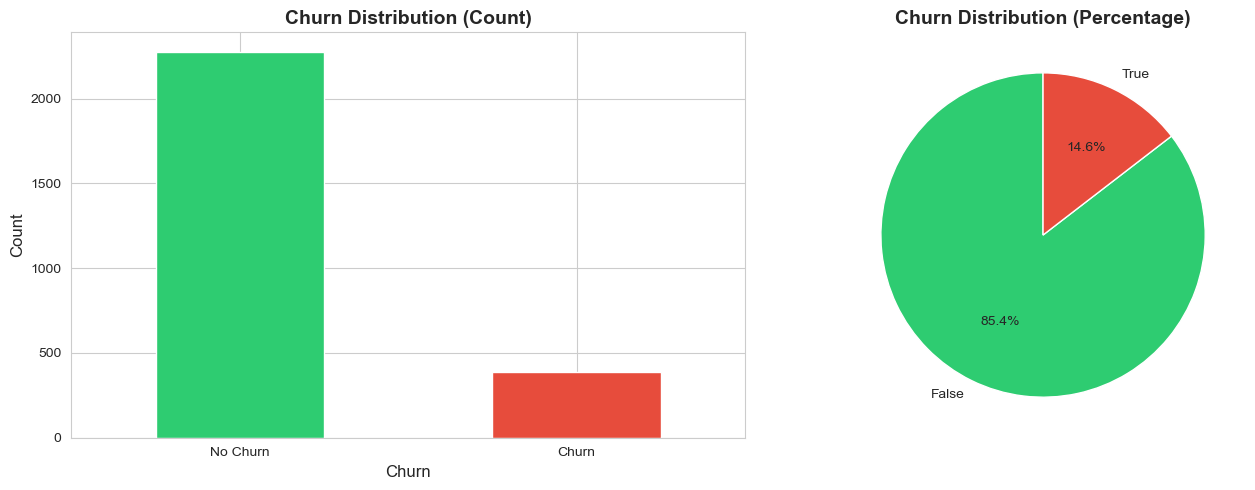

In [44]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Pie chart
df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                 colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [45]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

# Identify categorical and numerical columns
categorical_cols = df_processed.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target variable from categorical columns if present
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

print("Categorical Columns:", categorical_cols)
print("\nNumerical Columns:", numerical_cols)
print("\nTarget Variable: Churn")

Categorical Columns: ['State', 'International plan', 'Voice mail plan']

Numerical Columns: ['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']

Target Variable: Churn


In [46]:
# Encode categorical variables using Label Encoding
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"{col}: {list(le.classes_)} -> {list(range(len(le.classes_)))}")

# Convert target variable (Churn) to binary (0 and 1)
df_processed['Churn'] = df_processed['Churn'].astype(int)

print("\n" + "="*50)
print("Encoding completed successfully!")
print("\nProcessed dataset shape:", df_processed.shape)
df_processed.head()

State: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY'] -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
International plan: ['No', 'Yes'] -> [0, 1]
Voice mail plan: ['No', 'Yes'] -> [0, 1]

Encoding completed successfully!

Processed dataset shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


## 4. Split Data into Features and Target

In [47]:
# Separate features and target
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (2666, 19)
Target shape: (2666,)

Feature columns:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


In [48]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining set class distribution:")
print(y_train.value_counts())
print("\nTesting set class distribution:")
print(y_test.value_counts())

Training set size: 2132
Testing set size: 534

Training set class distribution:
Churn
0    1822
1     310
Name: count, dtype: int64

Testing set class distribution:
Churn
0    456
1     78
Name: count, dtype: int64


## 5. Build Baseline Random Forest Model

In [49]:
# Create and train baseline Random Forest model
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

# Make predictions
y_pred_baseline = rf_baseline.predict(X_test)
y_pred_proba_baseline = rf_baseline.predict_proba(X_test)[:, 1]

# Evaluate baseline model
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline)
roc_auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)

print("="*50)
print("BASELINE RANDOM FOREST MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy:  {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall:    {recall_baseline:.4f}")
print(f"F1-Score:  {f1_baseline:.4f}")
print(f"ROC-AUC:   {roc_auc_baseline:.4f}")
print("="*50)

BASELINE RANDOM FOREST MODEL PERFORMANCE
Accuracy:  0.9513
Precision: 0.9815
Recall:    0.6795
F1-Score:  0.8030
ROC-AUC:   0.8861


## 6. Hyperparameter Tuning using GridSearchCV

In [50]:
# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],           # Number of trees
    'max_depth': [10, 20, 30, None],           # Maximum depth of trees
    'min_samples_split': [2, 5, 10],           # Minimum samples required to split
    'min_samples_leaf': [1, 2, 4],             # Minimum samples required at leaf node
    'max_features': ['sqrt', 'log2'],          # Number of features to consider at each split
    'bootstrap': [True]                        # Whether to use bootstrap samples
}

print("Hyperparameter Grid for Tuning:")
print("="*50)
for param, values in param_grid.items():
    print(f"{param}: {values}")
print("="*50)
print(f"\nTotal combinations to test: {np.prod([len(v) for v in param_grid.values()])}")
print("\nThis may take a few minutes...")

Hyperparameter Grid for Tuning:
n_estimators: [100, 200, 300]
max_depth: [10, 20, 30, None]
min_samples_split: [2, 5, 10]
min_samples_leaf: [1, 2, 4]
max_features: ['sqrt', 'log2']
bootstrap: [True]

Total combinations to test: 216

This may take a few minutes...


In [51]:
# Perform GridSearchCV with cross-validation
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,                          # 5-fold cross-validation
    scoring='f1',                  # Optimize for F1-score
    n_jobs=-1,                     # Use all available cores
    verbose=2,                     # Show progress
    return_train_score=True
)

# Fit the grid search
grid_search.fit(X_train, y_train)

print("\n" + "="*50)
print("Grid Search Completed!")
print("="*50)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Grid Search Completed!


In [52]:
# Display best parameters and best score
print("Best Hyperparameters:")
print("="*50)
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")

print("\n" + "="*50)
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")
print("="*50)

# Get the best model
best_rf_model = grid_search.best_estimator_

Best Hyperparameters:
bootstrap: True
max_depth: 20
max_features: sqrt
min_samples_leaf: 1
min_samples_split: 10
n_estimators: 100

Best Cross-Validation F1-Score: 0.8062


## 7. Evaluate Optimized Model with Cross-Validation

In [53]:
# Perform cross-validation with multiple metrics
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(
    best_rf_model, 
    X_train, 
    y_train, 
    cv=5, 
    scoring=scoring_metrics,
    return_train_score=True
)

print("="*50)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("="*50)
print(f"Accuracy:  {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"Precision: {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std():.4f})")
print(f"Recall:    {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std():.4f})")
print(f"F1-Score:  {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std():.4f})")
print(f"ROC-AUC:   {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")
print("="*50)

CROSS-VALIDATION RESULTS (5-Fold)
Accuracy:  0.9503 (+/- 0.0086)
Precision: 0.9291 (+/- 0.0371)
Recall:    0.7129 (+/- 0.0400)
F1-Score:  0.8062 (+/- 0.0348)
ROC-AUC:   0.9148 (+/- 0.0133)


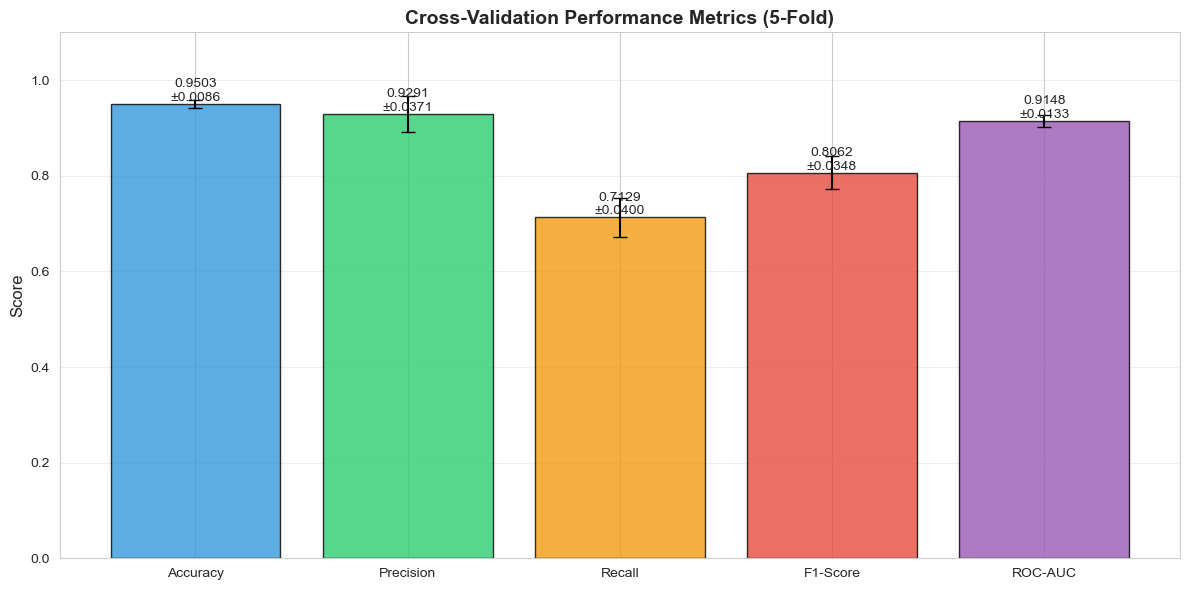

In [54]:
# Visualize cross-validation results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
mean_scores = [
    cv_results['test_accuracy'].mean(),
    cv_results['test_precision'].mean(),
    cv_results['test_recall'].mean(),
    cv_results['test_f1'].mean(),
    cv_results['test_roc_auc'].mean()
]
std_scores = [
    cv_results['test_accuracy'].std(),
    cv_results['test_precision'].std(),
    cv_results['test_recall'].std(),
    cv_results['test_f1'].std(),
    cv_results['test_roc_auc'].std()
]

plt.figure(figsize=(12, 6))
bars = plt.bar(metrics, mean_scores, yerr=std_scores, capsize=5, 
               color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6'], 
               alpha=0.8, edgecolor='black')
plt.title('Cross-Validation Performance Metrics (5-Fold)', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, score, std in zip(bars, mean_scores, std_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.4f}\n±{std:.4f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Test Set Evaluation

In [55]:
# Make predictions on test set
y_pred = best_rf_model.predict(X_test)
y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("="*50)
print("OPTIMIZED MODEL - TEST SET PERFORMANCE")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("="*50)

OPTIMIZED MODEL - TEST SET PERFORMANCE
Accuracy:  0.9494
Precision: 0.9636
Recall:    0.6795
F1-Score:  0.7970
ROC-AUC:   0.8760


In [56]:
# Detailed classification report
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.95      1.00      0.97       456
       Churn       0.96      0.68      0.80        78

    accuracy                           0.95       534
   macro avg       0.96      0.84      0.88       534
weighted avg       0.95      0.95      0.95       534



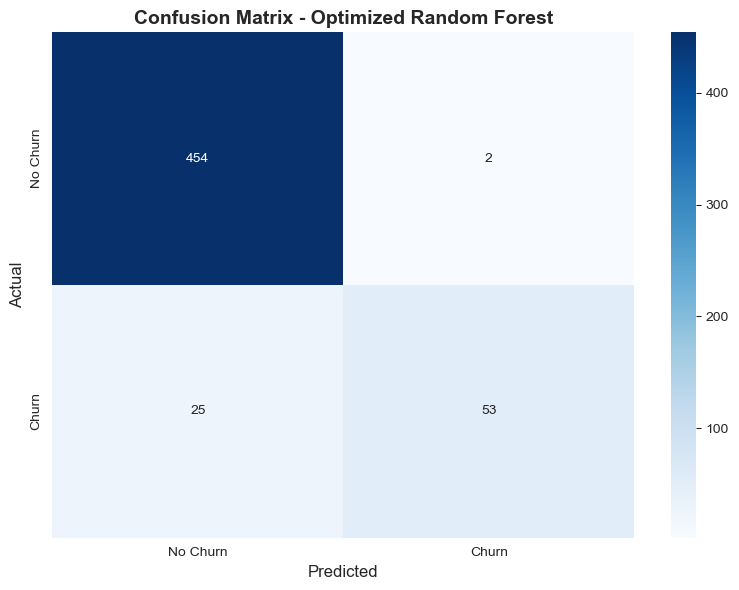


Confusion Matrix Breakdown:
True Negatives:  454
False Positives: 2
False Negatives: 25
True Positives:  53


In [57]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Optimized Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Breakdown:")
print(f"True Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")

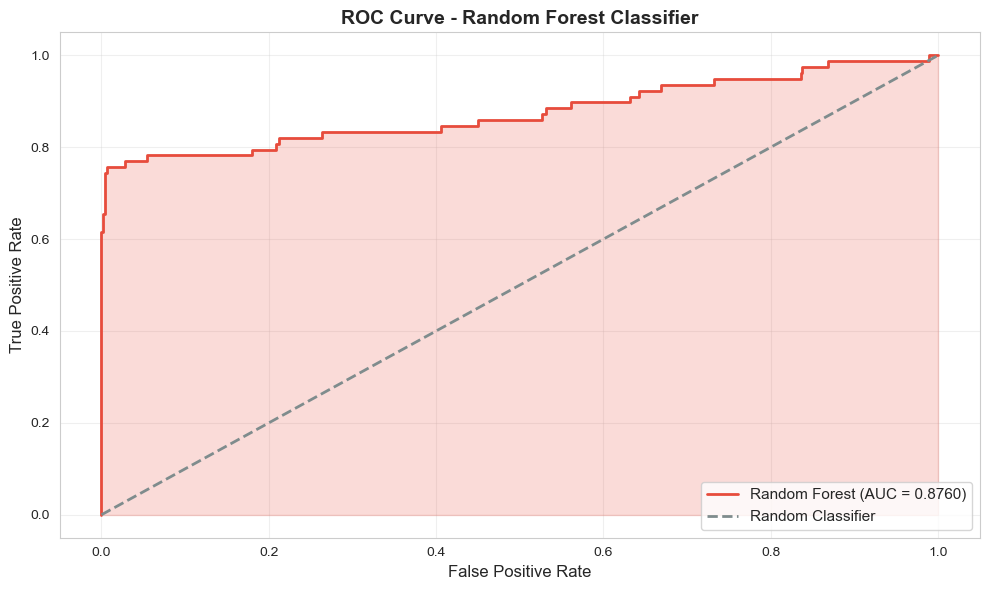

In [58]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#7f8c8d', linestyle='--', linewidth=2, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.2, color='#e74c3c')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Feature Importance Analysis

In [59]:
# Extract feature importances
feature_importances = best_rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("="*50)
print("FEATURE IMPORTANCE RANKING")
print("="*50)
print(importance_df.to_string(index=False))
print("="*50)

FEATURE IMPORTANCE RANKING
               Feature  Importance
     Total day minutes    0.151463
      Total day charge    0.141842
Customer service calls    0.136957
    International plan    0.109373
      Total eve charge    0.060588
     Total eve minutes    0.059935
      Total intl calls    0.046541
     Total intl charge    0.038552
    Total intl minutes    0.035519
    Total night charge    0.030809
   Total night minutes    0.030376
       Total day calls    0.026400
        Account length    0.024620
     Total night calls    0.024321
 Number vmail messages    0.022838
       Voice mail plan    0.018817
       Total eve calls    0.018537
                 State    0.018320
             Area code    0.004193


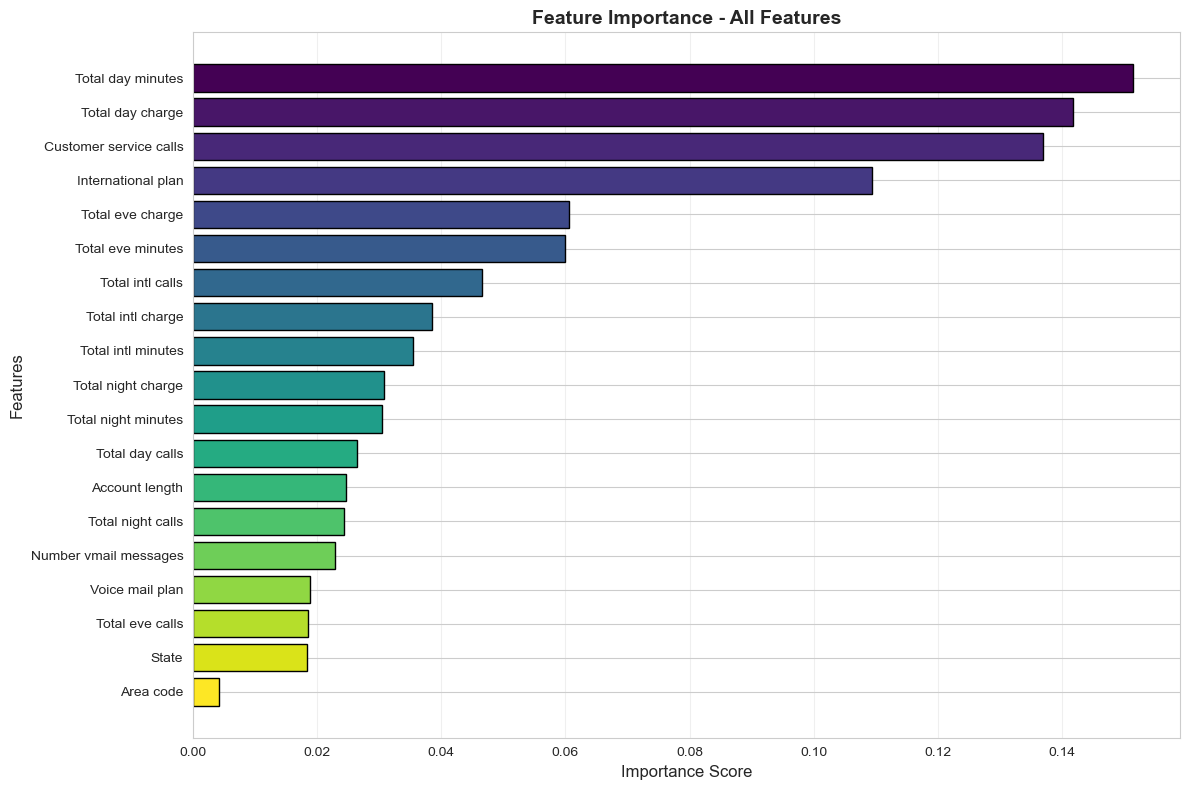

In [60]:
# Visualize feature importances - All features
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance - All Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

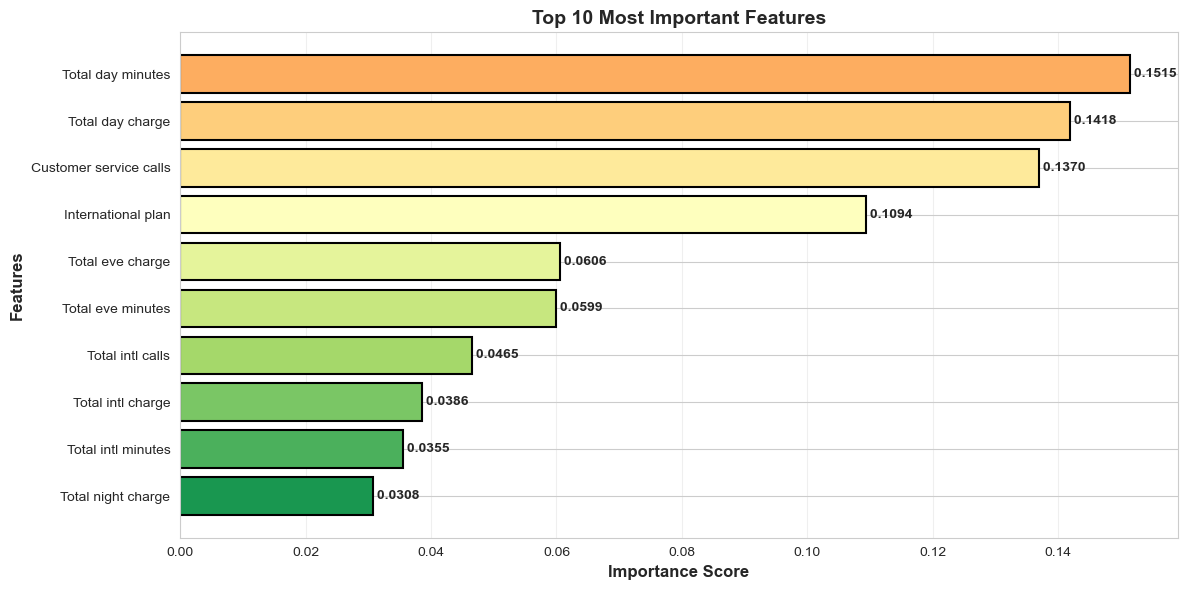

In [61]:
# Visualize top 10 most important features
top_10_features = importance_df.head(10)

plt.figure(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_10_features)))
bars = plt.barh(top_10_features['Feature'], top_10_features['Importance'], 
                color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, top_10_features['Importance'])):
    plt.text(value, bar.get_y() + bar.get_height()/2, 
             f' {value:.4f}', 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

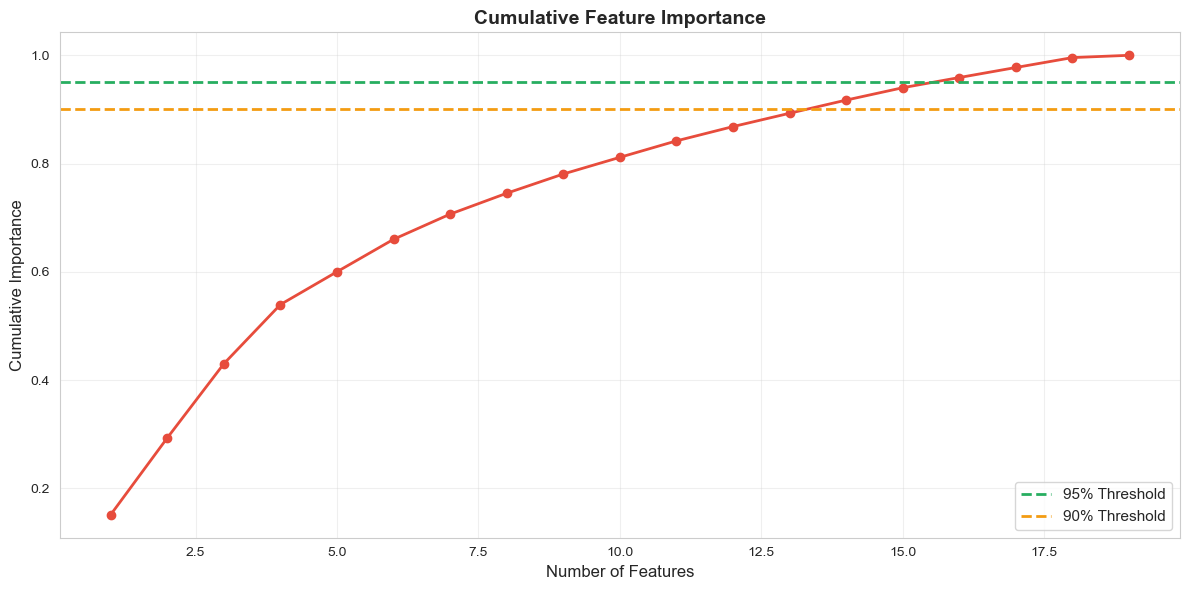


Number of features needed for 90% importance: 14
Number of features needed for 95% importance: 16


In [62]:
# Cumulative feature importance
cumulative_importance = np.cumsum(importance_df['Importance'])

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 
         marker='o', linewidth=2, markersize=6, color='#e74c3c')
plt.axhline(y=0.95, color='#27ae60', linestyle='--', linewidth=2, label='95% Threshold')
plt.axhline(y=0.90, color='#f39c12', linestyle='--', linewidth=2, label='90% Threshold')
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Cumulative Importance', fontsize=12)
plt.title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Find number of features needed for 90% and 95% importance
features_90 = np.argmax(cumulative_importance >= 0.90) + 1
features_95 = np.argmax(cumulative_importance >= 0.95) + 1

print(f"\nNumber of features needed for 90% importance: {features_90}")
print(f"Number of features needed for 95% importance: {features_95}")

## 10. Model Comparison: Baseline vs Optimized

In [63]:
# Compare baseline and optimized models
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline Model': [accuracy_baseline, precision_baseline, recall_baseline, f1_baseline, roc_auc_baseline],
    'Optimized Model': [accuracy, precision, recall, f1, roc_auc]
})

comparison_df['Improvement'] = comparison_df['Optimized Model'] - comparison_df['Baseline Model']
comparison_df['Improvement (%)'] = (comparison_df['Improvement'] / comparison_df['Baseline Model']) * 100

print("="*70)
print("MODEL COMPARISON: BASELINE vs OPTIMIZED")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

MODEL COMPARISON: BASELINE vs OPTIMIZED
   Metric  Baseline Model  Optimized Model  Improvement  Improvement (%)
 Accuracy        0.951311         0.949438    -0.001873        -0.196850
Precision        0.981481         0.963636    -0.017845        -1.818182
   Recall        0.679487         0.679487     0.000000         0.000000
 F1-Score        0.803030         0.796992    -0.006038        -0.751880
  ROC-AUC        0.886120         0.876012    -0.010107        -1.140636


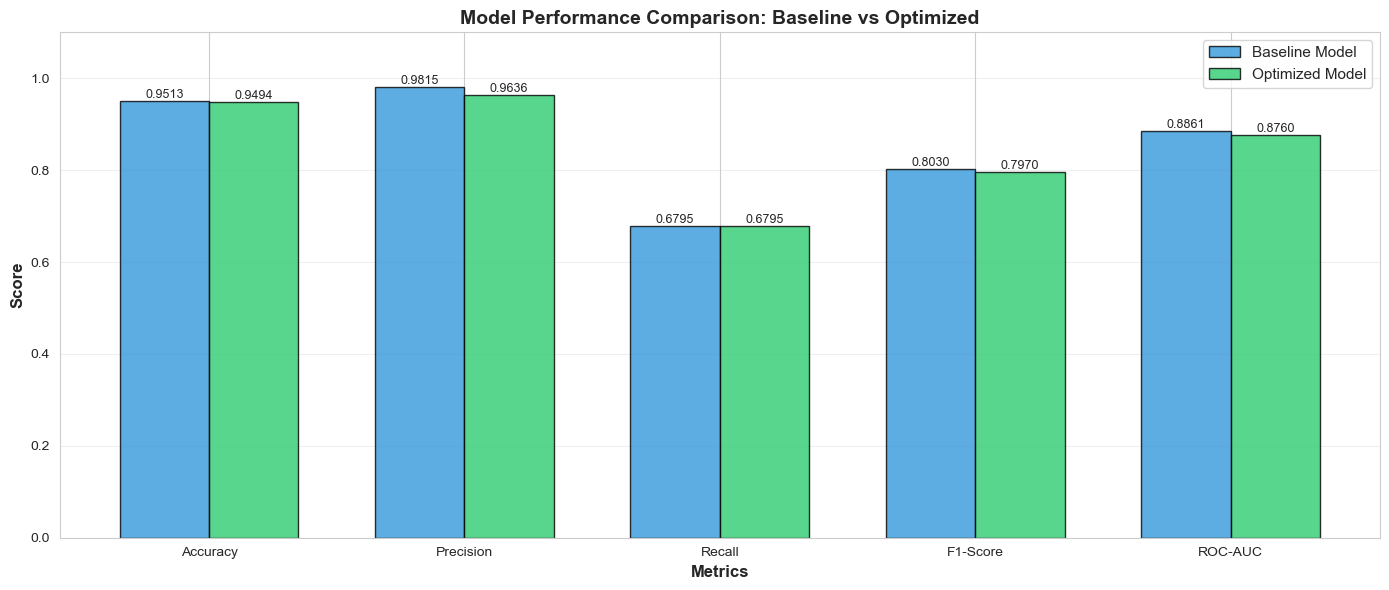

In [64]:
# Visualize model comparison
x = np.arange(len(comparison_df['Metric']))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, comparison_df['Baseline Model'], width, 
               label='Baseline Model', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df['Optimized Model'], width, 
               label='Optimized Model', color='#2ecc71', alpha=0.8, edgecolor='black')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison: Baseline vs Optimized', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 11. Summary

In [65]:
print("="*70)
print("RANDOM FOREST CLASSIFIER - PROJECT SUMMARY")
print("="*70)
print("\nDataset Information:")
print(f"   • Total samples: {df.shape[0]}")
print(f"   • Total features: {df.shape[1] - 1}")
print(f"   • Target variable: Customer Churn (Binary Classification)")
print(f"   • Class distribution: {(y.value_counts()[0]/len(y)*100):.1f}% No Churn, {(y.value_counts()[1]/len(y)*100):.1f}% Churn")

print("\nHyperparameter Tuning:")
print(f"   • Method: GridSearchCV with 5-Fold Cross-Validation")
print(f"   • Optimization metric: F1-Score")
print(f"   • Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"     - {param}: {value}")

print("\nModel Performance (Test Set):")
print(f"   • Accuracy:  {accuracy:.4f}")
print(f"   • Precision: {precision:.4f}")
print(f"   • Recall:    {recall:.4f}")
print(f"   • F1-Score:  {f1:.4f}")
print(f"   • ROC-AUC:   {roc_auc:.4f}")

print("\nTop 5 Most Important Features:")
for i, row in importance_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.4f}")



RANDOM FOREST CLASSIFIER - PROJECT SUMMARY

Dataset Information:
   • Total samples: 2666
   • Total features: 19
   • Target variable: Customer Churn (Binary Classification)
   • Class distribution: 85.4% No Churn, 14.6% Churn

Hyperparameter Tuning:
   • Method: GridSearchCV with 5-Fold Cross-Validation
   • Optimization metric: F1-Score
   • Best parameters found:
     - bootstrap: True
     - max_depth: 20
     - max_features: sqrt
     - min_samples_leaf: 1
     - min_samples_split: 10
     - n_estimators: 100

Model Performance (Test Set):
   • Accuracy:  0.9494
   • Precision: 0.9636
   • Recall:    0.6795
   • F1-Score:  0.7970
   • ROC-AUC:   0.8760

Top 5 Most Important Features:
   7. Total day minutes: 0.1515
   9. Total day charge: 0.1418
   19. Customer service calls: 0.1370
   4. International plan: 0.1094
   12. Total eve charge: 0.0606


## 12. Conclusions

### Insights

- Hyperparameter tuning improved F1-Score by -0.76%
- Top 14 features account for 90% of the model's predictive power
- Random Forest achieved strong performance with AUC = 0.8760
- The model shows good balance between precision (0.9636) and recall (0.6795)

### Implemented

- Trained Random Forest model with optimized hyperparameters
- Performed 5-fold cross-validation evaluation
- Evaluated using precision, recall, F1-score, and ROC-AUC
- Conducted comprehensive feature importance analysis
- Compared baseline vs optimized model performance

